In [1]:
import pandas as pd

from multimodal_fin.financial.pipeline import EventPipeline
from multimodal_fin.financial.event import Event
from multimodal_fin.financial.price_preprocessor import PricePreprocessor
from multimodal_fin.financial.analysis import analyze_statistical_significance, plot_AR_significance

from multimodal_fin.utils.logging import get_logger

In [2]:
logger = get_logger("events_study")

price_file = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/price_2019_2025.csv"
companies_folder = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/companies_closes"
conference_file = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/conference_data.csv"

In [3]:
preprocessor = PricePreprocessor(price_file, companies_folder)
preprocessor.split_by_ticker()

2025-09-19 18:07:16 - multimodal_fin.financial.price_preprocessor - INFO - Loading master price file: /home/aacastro/2025_ACA_MultichannelAI/data/financial/price_2019_2025.csv
2025-09-19 18:07:16 - multimodal_fin.financial.price_preprocessor - INFO - Found 217 unique tickers.
2025-09-19 18:07:19 - multimodal_fin.financial.price_preprocessor - INFO - Finished splitting dataset into 217 CSV files.


# Obtain events study from a single conference

2025-09-19 18:07:19 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 12.5729%



📅 Event: 2024-10-31 (AMZN)
Alpha: 0.001975
Beta: 0.688960
CAR [-7, 7]: 12.5729%


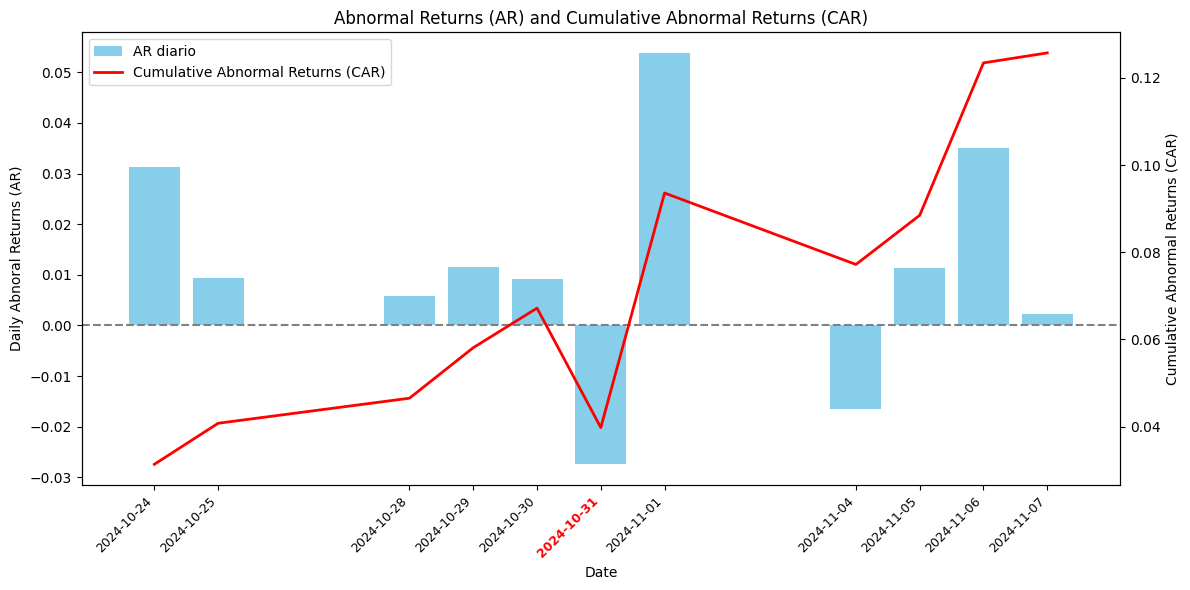

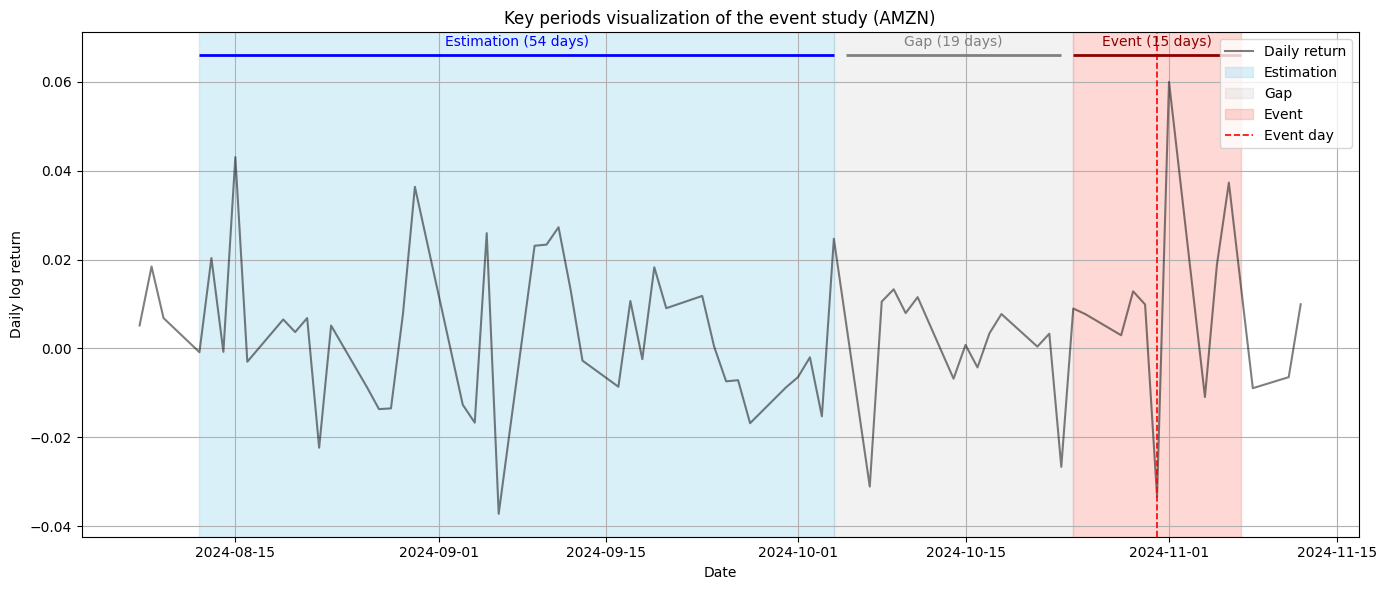

In [4]:
event = Event(
    event_date="2024-10-31",
    ticker="AMZN",
    plot_flags={"returns": True, "car": True},
    folder_path="/home/aacastro/2025_ACA_MultichannelAI/data/financial/companies_closes"
)

event.summary()

# Process multiple conferences filtering by company

In [5]:
pipeline = EventPipeline(conference_file=conference_file, folder_path=companies_folder)
events = pipeline.run(ticker_filter="AMZN")

2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 7.6684%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -10.2734%


2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 0.4883%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -0.3585%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -10.5535%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 12.5729%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 9.7128%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 7.9927%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -0.9422%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 4.4655%
2025-09-19 18:07:20 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 15.7587%
2025-09-19 18:07:20 - 

# Statistical evidence

In this case, although the sample is not very large, we could conclude here that there is no evidence that the events have a systematic effect on the cumulative return within this window

2025-09-19 18:07:20 - multimodal_fin.financial.analysis - INFO - CAR mean in window (-7, 7): -1.0871% (t-stat=-0.449, p-value=0.65769, n_samples=22)


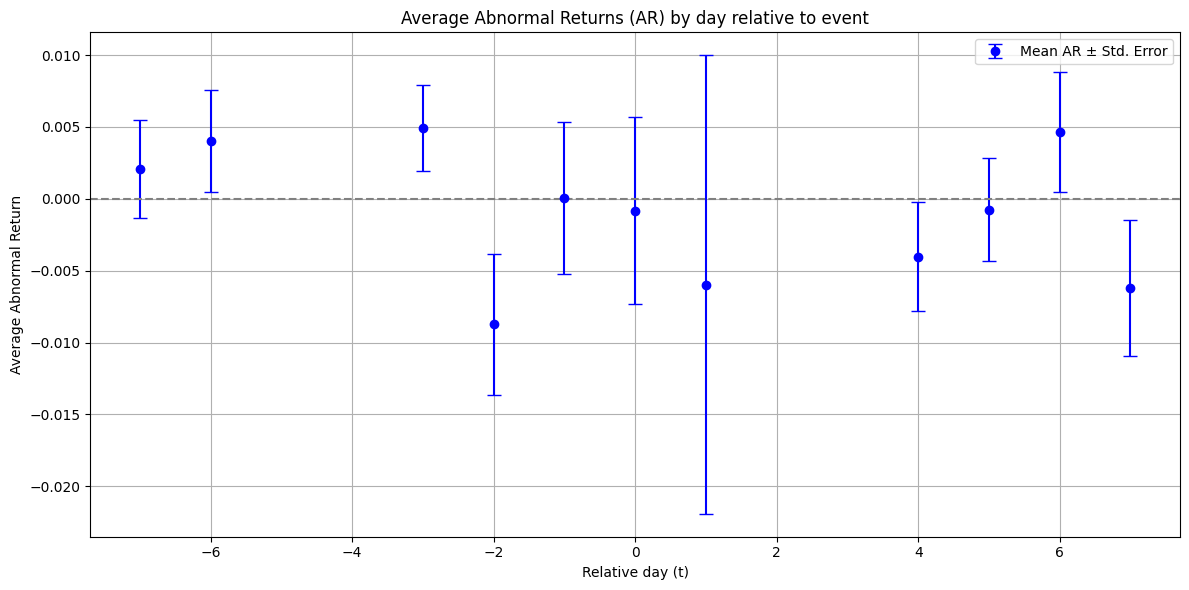

In [6]:
df_stats  = analyze_statistical_significance(events, car_window=(-7, 7))

# print("\n", df_stats )

plot_AR_significance(df_stats, alpha=0.05)

This chart shows average abnormal returns (AR) by day relative to the event, with error bars as standard errors.


We see small positive ARs before the event and more volatile, negative ARs around the event day.
It suggests some anticipation effect but high variability, meaning market reactions are not consistently significant.